In [1]:
import matplotlib.pyplot as plt

In [2]:
import seaborn as sns

In [3]:
import numpy as np

In [4]:
import pandas as pd

In [5]:
import scanpy as sc

In [6]:
import scvi

/opt/conda/envs/autoimmune/lib/python3.9/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: '/opt/conda/envs/autoimmune/lib/python3.9/site-packages/torchvision/image.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(
/opt/conda/envs/autoimmune/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
import gc

In [8]:
#pip install scikit-misc --force

In [9]:
print(scvi.__version__)

1.1.1


In [10]:
def reintegrate_subset(adata, n_hgv=2000, n_layers=3):
    adata_hvg = adata.copy()

    sc.pp.highly_variable_genes(
        adata_hvg, 
        flavor="seurat_v3", 
        n_top_genes=n_hgv, 
        layer="counts", 
        batch_key="dataset_id",
        subset=True
    )

    scvi.model.SCVI.setup_anndata(adata_hvg, layer="counts", batch_key="donor_id")

    vae = scvi.model.SCVI(adata_hvg, n_layers=n_layers, n_latent=30, gene_likelihood="nb")

    vae.train()

    adata_hvg.obsm["X_scVI"] = vae.get_latent_representation()
    
    print("KNN, UMAP, clustering ...")

    sc.pp.neighbors(adata_hvg, n_pcs=30, n_neighbors=20, use_rep="X_scVI", key_added="scvi_neighbors")

    sc.tl.umap(adata_hvg, min_dist=0.5, neighbors_key="scvi_neighbors", spread =1)

    sc.tl.leiden(adata_hvg, resolution=1, key_added="leiden", neighbors_key="scvi_neighbors")

    sc.set_figure_params(figsize=(8,8))

    print("Plot UMAP of with highly variable genes...") 
    sc.set_figure_params(figsize=(8,8))
    
    sc.pl.umap(
        adata_hvg,
        color=["dataset_id", "leiden"],
        frameon=False,
        size=5,
        ncols=1
    )


    #save umap
    adata.obsm["X_umap"] = adata_hvg.obsm["X_umap"]
    #save scvi model
    adata.obsm["X_scVI"] = vae.get_latent_representation()
    #save clusters
    adata.obs[["leiden"]] = adata_hvg.obs[["leiden"]]
    #Compute KNN
    sc.pp.neighbors(adata, n_pcs=30, n_neighbors=20, use_rep="X_scVI", key_added="scvi_neighbors")

    print("Plot UMAP of the full adata...")

    sc.pl.umap(
        adata,
        color=["leiden", "Cell_type_scANVI_asthma_skin"],
        frameon=False,
        size=5,
        ncols=1
    )
    

    return adata
    

In [11]:
def cross_table(
    adata,
    x,
    y,
    normalise=None,
    exclude_x=None,
    exclude_y=None,
    subset=None,
    sort=False,
    include_nan=False,
):
    """Make a cross table comparing two categorical annotations"""
    x_attr = adata.obs[x]
    y_attr = adata.obs[y]
    assert not _is_numeric(x_attr.values), f"Can not operate on numerical {x}"
    assert not _is_numeric(y_attr.values), f"Can not operate on numerical {y}"
    if include_nan:
        x_attr = x_attr.astype(str).astype("category")
        y_attr = y_attr.astype(str).astype("category")
    if subset is not None:
        x_attr = x_attr[subset]
        y_attr = y_attr[subset]
    selection = np.ones(x_attr.size, dtype=bool)
    if exclude_x:
        selection = selection & ~x_attr.isin(exclude_x)
    if exclude_y:
        selection = selection & ~y_attr.isin(exclude_y)
    x_attr = x_attr[selection]
    y_attr = y_attr[selection]

    if normalise in (0, "x", "xy", "row", "index"):
        norm_method = "index"
    elif normalise in (1, "y", "yx", "col", "columns"):
        norm_method = "columns"
    else:
        norm_method = False
    crs_tbl = pd.crosstab(x_attr, y_attr, dropna=False, normalize=norm_method)
    nx, ny = crs_tbl.shape
    if normalise in ("xy", "yx", "jaccard"):
        x_sizes = crs_tbl.sum(axis=1).values
        y_sizes = crs_tbl.sum(axis=0).values
        if normalise == "yx":
            normaliser = np.tile(x_sizes.reshape(nx, 1), (1, ny))
        elif normalise == "xy":
            normaliser = np.tile(y_sizes.reshape(1, ny), (nx, 1))
        else:
            normaliser = (
                np.tile(x_sizes.reshape(nx, 1), (1, ny))
                + np.tile(y_sizes.reshape(1, ny), (nx, 1))
                - crs_tbl.values
            )
        crs_tbl = (crs_tbl / normaliser).round(4)
    if sort in ("x", "index", "xy", "yx", "both"):
        crs_tbl = crs_tbl.sort_index()
    if sort in ("y", "columns", "xy", "yx", "both"):
        crs_tbl = crs_tbl.sort_columns()
    return crs_tbl

In [12]:
adata = sc.read_h5ad('Myeloid_B_T_From_Tissue_label_transfert_Subset_annotated_Milo_3K.h5ad')

In [13]:
adata.obs

,tissue,disease,donor_id,dataset_id,sex,development_stage,batch,majority_voting,conf_score,_scvi_batch,...,tissue_harmo,disease_short_2,tissue_short,disease_tissue,cell_type2,majority_voting_2,leiden_2,leiden_3,relabeled_cells_2,relabeled_cells_3
AAACCTGGTAGCACGA-1-1_0_0-0-0,Thyroid,Hashimoto’s thyroiditis,HT12Thyroid,Qian_Yue_Zhang_2022,NaN,NaN,0,Plasma cells,0.947648,91,...,Thyroid,hashimoto,thyroid,hashimoto_thyroid,NaN,NaN,NaN,NaN,NaN,NaN
AAACCTGGTCCGAGTC-1_0_0-0-0,Thyroid,Hashimoto’s thyroiditis,HT12Thyroid,Qian_Yue_Zhang_2022,NaN,NaN,0,Naive B cells,0.963530,91,...,Thyroid,hashimoto,thyroid,hashimoto_thyroid,NaN,NaN,NaN,NaN,NaN,NaN
AAACCTGTCAGTTAGC-1_0_0-0-0,Thyroid,Hashimoto’s thyroiditis,HT12Thyroid,Qian_Yue_Zhang_2022,NaN,NaN,0,Naive B cells,0.912090,91,...,Thyroid,hashimoto,thyroid,hashimoto_thyroid,NaN,NaN,NaN,NaN,NaN,NaN
AAAGATGTCCTAAGTG-1-1_0_0-0-0,Thyroid,Hashimoto’s thyroiditis,HT12Thyroid,Qian_Yue_Zhang_2022,NaN,NaN,0,Plasma cells,0.989998,91,...,Thyroid,hashimoto,thyroid,hashimoto_thyroid,NaN,NaN,NaN,NaN,NaN,NaN
AAAGCAATCTACGAGT-1_0_0-0-0,Thyroid,Hashimoto’s thyroiditis,HT12Thyroid,Qian_Yue_Zhang_2022,NaN,NaN,0,Naive B cells,0.775685,91,...,Thyroid,hashimoto,thyroid,hashimoto_thyroid,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTACTGTCATGGTCA-1-1-1-1-1-1-1_1_0_0-1-1-2,Retrosigmoid Colon,CD + Spondyloarthritis,Patient_2_Colon_GSM4976992,GSE163314_Lefferts_2021,NaN,NaN,2,Type 1 helper T cells,0.422139,33,...,Colon,CD_spondyloarthritis,NaN,NaN,7,B_plasma_IgA,5,5,Th1,Th1
TTTGCGCCATGCCCGA-1-1-1-1-1-1-1_1_0_0-1-1-2,Retrosigmoid Colon,CD + Spondyloarthritis,Patient_2_Colon_GSM4976992,GSE163314_Lefferts_2021,NaN,NaN,2,Type 1 helper T cells,0.398410,33,...,Colon,CD_spondyloarthritis,NaN,NaN,7,B_plasma_IgA,5,5,Th1,Th1
TTTGCGCGTAAACACA-1-1-1-1-1-1-1_1_0_0-1-1-2,Retrosigmoid Colon,CD + Spondyloarthritis,Patient_2_Colon_GSM4976992,GSE163314_Lefferts_2021,NaN,NaN,2,Type 1 helper T cells,0.421337,33,...,Colon,CD_spondyloarthritis,NaN,NaN,7,B_plasma_IgA,7,6,Th17,Th17
TTTGGTTCAATCCGAT-1-1-1-1-1-1-1_1_0_0-1-1-2,Retrosigmoid Colon,CD + Spondyloarthritis,Patient_2_Colon_GSM4976992,GSE163314_Lefferts_2021,NaN,NaN,2,Type 1 helper T cells,0.121884,33,...,Colon,CD_spondyloarthritis,NaN,NaN,"6,0",B_plasma_IgA,3,5,T follicular helper,T follicular helper


In [14]:
obs = pd.read_csv("Obs_Myeloid_B_T_From_PBMC_label_transfert_Subset_annotated_Milo_3K_with_UMAP_from_gpu_with_asthma_Skin_data.csv",
                 index_col=0)

/var/tmp/ipykernel_8037/1135807866.py:1: DtypeWarning: Columns (5,6,8,13,14,16,18,19,20,21,25,28,29,30,31,32,35,36,40,47,49,51) have mixed types. Specify dtype option on import or set low_memory=False.
  obs = pd.read_csv("Obs_Myeloid_B_T_From_PBMC_label_transfert_Subset_annotated_Milo_3K_with_UMAP_from_gpu_with_asthma_Skin_data.csv",


In [15]:
obs.Cell_type_scANVI_asthma_skin.value_counts()

Trm cytotoxic                  36673
Th17                           36456
Tem/Eff helper T               34474
Tem/Trm cytotoxic              33808
Mo-Mac CCL2+LYVE1+             33445
Mig DC                         32786
T regs                         28978
DC2                            22601
Naive B cells                  21894
Th1                            21830
T follicular helper            20698
Intermediate macrophage        16752
Memory B cells                 15505
Mac NUPR1_TREM2_hi             14703
Tcm/Naive helper T             14582
Mac1                           13865
NK_CD56bright                  12594
Plasma cells1                  10368
Plasma cells2                  10240
γδ T cells                      9180
Mac MERTK_hi_TREM2_low          8199
DC1                             7638
Plasma cells3                   7236
Trm_γδ                          7131
MAIT cell                       6864
ILC3                            6526
Proliferative GC B cells        6395
T

In [16]:
haniffaAd = sc.read_h5ad('haniffalab_QC.h5ad')

In [17]:
haniffaAd

AnnData object with n_obs × n_vars = 210443 × 33538
    obs: 'disease_status', 'Site', 'tissue_harmo', 'Enrichment', 'Location', 'donor_id', 'sex', 'age', 'development_stage', 'cell_type', 'tissue', 'dataset_id', 'doublet_scores', 'predicted_doublets', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_rb', 'pct_counts_rb', 'QC', 'n_genes'
    var: 'gene_ids-SKN8090524', 'feature_types-SKN8090524', 'mt', 'rb', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
    uns: 'log1p'
    layers: 'counts'

In [18]:
print(haniffaAd.X[100:200])

  (0, 27)	2.838228940963745
  (0, 38)	2.838228940963745
  (0, 55)	2.838228940963745
  (0, 104)	2.838228940963745
  (0, 154)	2.838228940963745
  (0, 178)	2.838228940963745
  (0, 190)	2.838228940963745
  (0, 451)	2.838228940963745
  (0, 491)	2.838228940963745
  (0, 493)	3.3751940727233887
  (0, 504)	2.838228940963745
  (0, 555)	2.838228940963745
  (0, 559)	2.838228940963745
  (0, 584)	2.838228940963745
  (0, 704)	2.838228940963745
  (0, 733)	2.838228940963745
  (0, 865)	3.0750572681427
  (0, 875)	2.838228940963745
  (0, 888)	2.838228940963745
  (0, 904)	2.838228940963745
  (0, 918)	3.1951661109924316
  (0, 935)	3.1951661109924316
  (0, 1045)	2.838228940963745
  (0, 1259)	2.838228940963745
  (0, 1297)	2.838228940963745
  :	:
  (99, 32753)	2.54604172706604
  (99, 32767)	2.642083168029785
  (99, 32795)	1.8231158256530762
  (99, 32829)	2.54604172706604
  (99, 32883)	1.8231158256530762
  (99, 32976)	2.642083168029785
  (99, 32977)	2.210798501968384
  (99, 32978)	1.8231158256530762
  (99, 3324

In [19]:
#haniffaAd.obs.columns
haniffaAd.obs.cell_type.value_counts()

Th                    55168
nan                   34175
Tc                    15952
Treg                  13071
Inf_mono               7970
moDC_1                 7464
Macro_1                7179
Mono                   7131
LC_3                   6231
LC_4                   5897
moDC_2                 5534
Pericyte_2_inflamm     5253
DC2                    5113
LE2                    5091
LC_2                   4747
MigDC                  4408
ILC1_3                 3932
moDC_3                 3815
ILC1_NK                3323
Macro_2                2710
DC1                    1936
LC_1                   1812
Mast_cell               897
NK                      886
ILC2                    666
Plasma                   82
Name: cell_type, dtype: int64

In [20]:
removed_cells = ['Differentiated_KC', 'Proliferating_KC', 'VE2', 'F2', 'Undifferentiated_KC*', #'LE2', 'Pericyte_2_inflamm',
                                                           'Differentiated_KC*', 'F1', 'VE1', 'F3', 'Pericyte_1_non_inflamm', 'Melanocyte',
                                                           'VE3', 'LE1', 'Schwann1', 'Schwann2']

In [21]:
removed_cells

['Differentiated_KC',
 'Proliferating_KC',
 'VE2',
 'F2',
 'Undifferentiated_KC*',
 'Differentiated_KC*',
 'F1',
 'VE1',
 'F3',
 'Pericyte_1_non_inflamm',
 'Melanocyte',
 'VE3',
 'LE1',
 'Schwann1',
 'Schwann2']

In [22]:
haniffaAd = haniffaAd[~haniffaAd.obs.cell_type.isin(removed_cells)]

In [23]:
haniffaAd.var = haniffaAd.var[['gene_ids-SKN8090524', 'feature_types-SKN8090524']]

In [24]:
#haniffaAd.obs["tissue"] = haniffaAd.obs.Tissue
haniffaAd.obs["dataset_id"] = "Skin_Reynolds_et_al"

In [25]:
haniffaAd.obs.columns

Index(['disease_status', 'Site', 'tissue_harmo', 'Enrichment', 'Location',
       'donor_id', 'sex', 'age', 'development_stage', 'cell_type', 'tissue',
       'dataset_id', 'doublet_scores', 'predicted_doublets',
       'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt',
       'total_counts_rb', 'pct_counts_rb', 'QC', 'n_genes'],
      dtype='object')

In [26]:
#haniffaAd.obs.columns = ['disease_status', 'Site', 'tissue_harmo', 'Enrichment', 'Location', 
 #                        'donor_id', 'sex', 'age', 'development_stage', 'cell_type', 'tissue', 'dataset_id']

In [27]:
adata_Braga = sc.read_h5ad("Braga_asthma_lung_celltypist.h5ad")

In [28]:
adata_Braga = adata_Braga[adata_Braga.obs.main_predicted_cell_groups.isin(['Classical monocytes', 'Mast cells', 'CD4 T cells', 
                                                           'DC2', 'CD8 T cells', 'Non-classical monocytes', 'NK cells', 
                                                           'B cells', 'Alveolar macrophages', 'Plasmacytoid DCs', 'Plasma cells'])].copy()

In [29]:
adata_query = adata_Braga.concatenate(haniffaAd, batch_key="ref_query")

/var/tmp/ipykernel_8037/1405389183.py:1: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata_query = adata_Braga.concatenate(haniffaAd, batch_key="ref_query")


In [30]:
adata.shape

(365203, 17267)

In [31]:
obs.shape

(588646, 56)

In [32]:
del haniffaAd
del adata_Braga
adata_query

AnnData object with n_obs × n_vars = 228696 × 31915
    obs: 'dataset_id', 'donor_id', 'tissue', 'cell_source', 'disease', 'disease_status', 'age', 'sex', 'developmental_stage', 'sample_id', 'n_counts', 'doublet_scores', 'predicted_doublets', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_rb', 'pct_counts_rb', 'QC', 'n_genes', 'predicted_labels', 'over_clustering', 'majority_voting', 'conf_score', 'main_predicted_cell_groups', 'leiden', 'Site', 'tissue_harmo', 'Enrichment', 'Location', 'development_stage', 'cell_type', 'ref_query'
    var: 'gene_ids-SKN8090524-1', 'feature_types-SKN8090524-1'
    layers: 'counts'

In [33]:
adata = adata.concatenate(adata_query, batch_key="ref_query")

/var/tmp/ipykernel_8037/296564144.py:1: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata = adata.concatenate(adata_query, batch_key="ref_query")


In [34]:
adata = adata[obs.index, :]

In [35]:
del adata_query
gc.collect()

1028

In [36]:
adata.shape

(588646, 17209)

In [37]:
adata.obs = obs.copy()

In [38]:
obs.Cell_type_scANVI_asthma_skin.unique()

array(['Plasma cells1', 'Naive B cells', 'Plasma cells3', 'T/B doublets',
       'Memory B cells', 'Proliferative GC B cells', 'MNP/B doublets',
       'ABCs', 'Plasmablasts', 'GC B cells1', 'Plasma cells2',
       'IgM plasma cells', 'Mac TREM2_hi', 'Mac MERTK_hi_TREM2_low',
       'DC2', 'Mac2', 'Mac S100A8 prod', 'Intermediate macrophage',
       'Cycling', 'Mo-Mac LYVE1+', 'DC1', 'Mac1', 'Mac NUPR1_TREM2_hi',
       'Mig DC', 'Mo-Mac_CX3CR1', 'Mo-Mac', 'Mo-Mac CCL2+LYVE1+',
       'Mo-Mac LYVE1- CCL2+', 'pDC', 'Mast cell', 'Tem/Trm cytotoxic',
       'Tem/Eff helper T', 'MAIT cell', 'T follicular helper', 'CD4',
       'Th1', 'Trm cytotoxic INFGhi', 'T regs',
       'Tem/Trm cytotoxic_Syn-Fluid', 'Tcm/Naive helper T',
       'PD1 CD4 T cells', 'Cycl Treg', 'Trm cytotoxic', 'ILC3',
       'NK_CD56bright', 'Trm_γδ', 'Cycl CD8', 'TCD4_CM/T_Naive_Syn-Fluid',
       'CD8_ZNF683+', 'NK_CD16hi', 'Tcm/Naive cytotoxic T cells', 'Th17',
       'Cycl NK', 'γδ T cells', 'Th1/Th17_gut', 'Trm_gu

In [39]:
len(obs.Cell_type_scANVI_asthma_skin.unique())

56

In [40]:
adata[adata.obs.cell_type.isna()].obs.dataset_id.value_counts()

Skin_Reynolds_et_al    34175
Braga_asthma           18253
Name: dataset_id, dtype: int64

In [41]:
adata.shape

(588646, 17209)

In [42]:
adata=adata[~(adata.obs.cell_type.isna() & adata.obs.dataset_id.isin(["Skin_Reynolds_et_al"]))]

In [43]:
adata.shape

(554471, 17209)

In [44]:
myel = ['Mac TREM2_hi', 'Mac MERTK_hi_TREM2_low',
       'DC2', 'Mac2', 'Mac S100A8 prod', 'Intermediate macrophage',
       'Cycling', 'Mo-Mac LYVE1+', 'DC1', 'Mac1', 'Mac NUPR1_TREM2_hi',
       'Mig DC', 'Mo-Mac_CX3CR1', 'Mo-Mac', 'Mo-Mac CCL2+LYVE1+',
       'Mo-Mac LYVE1- CCL2+', 'pDC', 'Mast cell']

len(myel)

18

In [45]:
t_cell = ['Tem/Trm cytotoxic', 'Tem/Eff helper T', 'MAIT cell', 'T follicular helper', 'CD4',
       'Th1', 'Trm cytotoxic INFGhi', 'T regs',
       'Tem/Trm cytotoxic_Syn-Fluid', 'Tcm/Naive helper T',
       'PD1 CD4 T cells', 'Cycl Treg', 'Trm cytotoxic', 'ILC3',
       'NK_CD56bright', 'Trm_γδ', 'Cycl CD8', 'TCD4_CM/T_Naive_Syn-Fluid',
       'CD8_ZNF683+', 'NK_CD16hi', 'Tcm/Naive cytotoxic T cells', 'Th17',
       'Cycl NK', 'γδ T cells', 'Th1/Th17_gut', 'Trm_gut']

len(t_cell)

26

In [46]:
b_cell = ['Plasma cells1', 'Naive B cells', 'Plasma cells3', 'T/B doublets',
       'Memory B cells', 'Proliferative GC B cells', 'MNP/B doublets',
       'ABCs', 'Plasmablasts', 'GC B cells1', 'Plasma cells2',
       'IgM plasma cells']

len(b_cell)

12

In [47]:
del obs
#del adata_query
gc.collect()

3205

### Myeloid

In [48]:
adata_myeloid = adata[adata.obs.Cell_type_scANVI_asthma_skin.isin(myel)].copy()

In [49]:
adata_myeloid

AnnData object with n_obs × n_vars = 154221 × 17209
    obs: 'tissue', 'disease', 'donor_id', 'dataset_id', 'sex', 'development_stage', 'batch', 'majority_voting', 'conf_score', '_scvi_batch', 'cell_type', '_scvi_labels', 'barcodes', 'disease_status', 'age', 'developmental_stage', 'barcode', 'sample_id', 'Site', 'Enrichment', 'Location', 'full_clustering', 'log1p_total_counts', 'Cell_type_scANVI', 'disease_short', 'nhood_kth_distance', 'tissue_harmo', 'disease_short_2', 'tissue_short', 'disease_tissue', 'cell_type2', 'majority_voting_2', 'leiden_2', 'leiden_3', 'relabeled_cells_2', 'relabeled_cells_3', 'cell_source', 'n_counts', 'doublet_scores', 'predicted_doublets', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_rb', 'pct_counts_rb', 'QC', 'n_genes', 'predicted_labels', 'over_clustering', 'main_predicted_cell_groups', 'leiden', 'ref_query', 'disease_label_trans', 'scanvi_predictions', 'Cell_type_scANVI_asthma_skin'
    var: 'mt-0-0', 'rb-0-0', 

In [ ]:
adata_myeloid = reintegrate_subset(adata=adata_myeloid, n_hgv=3000, n_layers=3)

/opt/conda/envs/autoimmune/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:64: UserWarning: `flavor='seurat_v3'` expects raw count data, but non-integers were found.
  warnings.warn(
/opt/conda/envs/autoimmune/lib/python3.9/site-packages/scvi/data/fields/_base_field.py:64: UserWarning: adata.layers[counts] does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Epoch 47/52:  88%|████████▊ | 46/52 [08:08<01:02, 10.38s/it, v_num=1, train_loss_step=811, train_loss_epoch=831]

In [51]:
adata_myeloid

AnnData object with n_obs × n_vars = 154221 × 17209
    obs: 'tissue', 'disease', 'donor_id', 'dataset_id', 'sex', 'development_stage', 'batch', 'majority_voting', 'conf_score', '_scvi_batch', 'cell_type', '_scvi_labels', 'barcodes', 'disease_status', 'age', 'developmental_stage', 'barcode', 'sample_id', 'Site', 'Enrichment', 'Location', 'full_clustering', 'log1p_total_counts', 'Cell_type_scANVI', 'disease_short', 'nhood_kth_distance', 'tissue_harmo', 'disease_short_2', 'tissue_short', 'disease_tissue', 'cell_type2', 'majority_voting_2', 'leiden_2', 'leiden_3', 'relabeled_cells_2', 'relabeled_cells_3', 'cell_source', 'n_counts', 'doublet_scores', 'predicted_doublets', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_rb', 'pct_counts_rb', 'QC', 'n_genes', 'predicted_labels', 'over_clustering', 'main_predicted_cell_groups', 'leiden', 'ref_query', 'disease_label_trans', 'scanvi_predictions', 'Cell_type_scANVI_asthma_skin'
    var: 'mt-0-0', 'rb-0-0', 

In [ ]:
adata_myeloid.obs['Cell_type_scANVI2'] = adata_myeloid.obs.Cell_type_scANVI_asthma_skin

In [ ]:
#cmtx = sc.metrics.confusion_matrix("Cell_type_scANVI2", "Cell_type_scANVI", adata_myeloid.obs)
#sns.heatmap(cmtx)

In [ ]:
sc.pl.umap(
    adata_myeloid,
    color=['Cell_type_scANVI_asthma_skin', 'cell_type'],
    frameon=False,
    size=2,
    ncols=1,
    use_raw=True,
    #legend_loc="on data"
)

In [ ]:
for dat in adata_myeloid.obs.dataset_id.unique():
    sc.pl.umap(
    adata_myeloid,
    groups = dat,
    color="dataset_id",
    frameon=False,
    size=5,
    ncols=1,
    use_raw=True,
    #legend_loc="on data"
)

In [63]:
adata_myeloid.obs = adata_myeloid.obs[['tissue', 'disease', 'donor_id', 'dataset_id', 'sex',
       'development_stage', 'batch', 'majority_voting', 'conf_score',
       '_scvi_batch', 'cell_type', '_scvi_labels', 'barcodes',
       'disease_status', 'age', 'developmental_stage', 'barcode', 'sample_id',
       'Site', 'Enrichment', 'Location', 'full_clustering',
       'log1p_total_counts', 'Cell_type_scANVI', 'disease_short',
       'nhood_kth_distance', 'tissue_harmo', 'disease_short_2', 'tissue_short',
       'disease_tissue', 'cell_source',
       'n_counts', 'doublet_scores', 'predicted_labels', 'over_clustering',
       'main_predicted_cell_groups', 'leiden', 'ref_query',
       'disease_label_trans', 'Cell_type_scANVI2']]

In [64]:
adata_myeloid.obs.tissue_short = adata_myeloid.obs.tissue_short.astype("category")

/var/tmp/ipykernel_1011977/3767532251.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  adata_myeloid.obs.tissue_short = adata_myeloid.obs.tissue_short.astype("category")


In [65]:
adata_myeloid.write_h5ad("result_scvi/Myeloid_B_T_From_Tissue/scVI_after_label_trans/Myeloid_From_Tissue_Subset_with_asthma_skin.h5ad")

In [66]:
del adata_myeloid
gc.collect()

102333

### T cell

In [57]:
adata_t_cell = adata[adata.obs.Cell_type_scANVI_asthma_skin.isin(t_cell)].copy()

In [58]:
adata_t_cell

AnnData object with n_obs × n_vars = 314773 × 17209
    obs: 'tissue', 'disease', 'donor_id', 'dataset_id', 'sex', 'development_stage', 'batch', 'majority_voting', 'conf_score', '_scvi_batch', 'cell_type', '_scvi_labels', 'barcodes', 'disease_status', 'age', 'developmental_stage', 'barcode', 'sample_id', 'Site', 'Enrichment', 'Location', 'full_clustering', 'log1p_total_counts', 'Cell_type_scANVI', 'disease_short', 'nhood_kth_distance', 'tissue_harmo', 'disease_short_2', 'tissue_short', 'disease_tissue', 'cell_type2', 'majority_voting_2', 'leiden_2', 'leiden_3', 'relabeled_cells_2', 'relabeled_cells_3', 'cell_source', 'n_counts', 'doublet_scores', 'predicted_doublets', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_rb', 'pct_counts_rb', 'QC', 'n_genes', 'predicted_labels', 'over_clustering', 'main_predicted_cell_groups', 'leiden', 'ref_query', 'disease_label_trans', 'scanvi_predictions', 'Cell_type_scANVI_asthma_skin'
    var: 'mt-0-0', 'rb-0-0', 

In [ ]:
adata_t_cell = reintegrate_subset(adata=adata_t_cell, n_hgv=5000, n_layers=3)

/opt/conda/envs/autoimmune/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:64: UserWarning: `flavor='seurat_v3'` expects raw count data, but non-integers were found.
  warnings.warn(
/opt/conda/envs/autoimmune/lib/python3.9/site-packages/scvi/data/fields/_base_field.py:64: UserWarning: adata.layers[counts] does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Epoch 18/25:  68%|██████▊   | 17/25 [06:47<03:11, 23.97s/it, v_num=1, train_loss_step=1.66e+3, train_loss_epoch=1.59e+3]

In [ ]:
adata_t_cell.obs['Cell_type_scANVI2'] = adata_t_cell.obs["Cell_type_scANVI_asthma_skin"]

In [ ]:
#cmtx = sc.metrics.confusion_matrix("Cell_type_scANVI2", "Cell_type_scANVI", adata_t_cell.obs)
#sns.heatmap(cmtx)

In [ ]:
sc.set_figure_params(figsize=(10, 10))
sc.pl.umap(
    adata_t_cell,
    color=['Cell_type_scANVI_asthma_skin'],
    frameon=False,
    size=2,
    ncols=1,
    use_raw=True,
    legend_loc="on data"
)

In [ ]:
adata_t_cell.obs = adata_t_cell.obs[['tissue', 'disease', 'donor_id', 'dataset_id', 'sex',
       'development_stage', 'batch', 'majority_voting', 'conf_score',
       '_scvi_batch', 'cell_type', '_scvi_labels', 'barcodes',
       'disease_status', 'age', 'developmental_stage', 'barcode', 'sample_id',
       'Site', 'Enrichment', 'Location', 'full_clustering',
       'log1p_total_counts', 'Cell_type_scANVI', 'disease_short',
       'nhood_kth_distance', 'tissue_harmo', 'disease_short_2', 'tissue_short',
       'disease_tissue', 'cell_source',
       'n_counts', 'doublet_scores', 'predicted_labels', 'over_clustering',
       'main_predicted_cell_groups', 'leiden', 'ref_query',
       'disease_label_trans', 'Cell_type_scANVI2']]

In [ ]:
adata_t_cell.obs.tissue_short = adata_t_cell.obs.tissue_short.astype("category")

In [ ]:
for dat in adata_t_cell.obs.dataset_id.unique():
    sc.pl.umap(
    adata_t_cell,
    groups = dat,
    color="dataset_id",
    frameon=False,
    size=5,
    ncols=1,
    use_raw=True,
    #legend_loc="on data"
)

In [ ]:
adata_t_cell.write_h5ad("result_scvi/Myeloid_B_T_From_Tissue/scVI_after_label_trans/T_cells_From_Tissue_Subset_with_asthma_skin.h5ad")

In [ ]:
del adata_t_cell
gc.collect()

### B cell

In [44]:
adata_b_cell = adata[adata.obs.Cell_type_scANVI_asthma_skin.isin(b_cell)].copy()

In [45]:
adata_b_cell.obs.dataset_id.value_counts()

dataset_id
GSE121380_Huang_2019           23299
Qian_Yue_Zhang_2022            20035
Elmentaite_2020                18054
GSE134809_Martin_et_al_2019    16819
Skin_Reynolds_et_al             5501
GSE163314_Lefferts_2021         3081
Braga_asthma                    1383
E-MTAB-8322_Stefeno_2020        1046
Name: count, dtype: int64

In [46]:
adata_b_cell = adata_b_cell[adata_b_cell.obs.dataset_id != "Martin_JIA_2019"]


/opt/conda/envs/autoimmune/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:64: UserWarning: `flavor='seurat_v3'` expects raw count data, but non-integers were found.
  warnings.warn(
/opt/conda/envs/autoimmune/lib/python3.9/abc.py:119: FutureWarning: SparseDataset is deprecated and will be removed in late 2024. It has been replaced by the public classes CSRDataset and CSCDataset.

For instance checks, use `isinstance(X, (anndata.experimental.CSRDataset, anndata.experimental.CSCDataset))` instead.

For creation, use `anndata.experimental.sparse_dataset(X)` instead.

  return _abc_instancecheck(cls, instance)
An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.
/opt/conda/envs/autoimmune/lib/python3.9/site-packages/scvi/data/fields/_base_field.py:64: UserWarning: adata.layers[counts] does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)
/opt/conda/envs

Epoch 90/90: 100%|██████████| 90/90 [09:43<00:00,  6.56s/it, v_num=1, train_loss_step=689, train_loss_epoch=675]

`Trainer.fit` stopped: `max_epochs=90` reached.


Epoch 90/90: 100%|██████████| 90/90 [09:43<00:00,  6.48s/it, v_num=1, train_loss_step=689, train_loss_epoch=675]
KNN, UMAP, clustering ...
Plot UMAP of with highly variable genes...


/opt/conda/envs/autoimmune/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/opt/conda/envs/autoimmune/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/opt/conda/envs/autoimmune/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/opt/conda

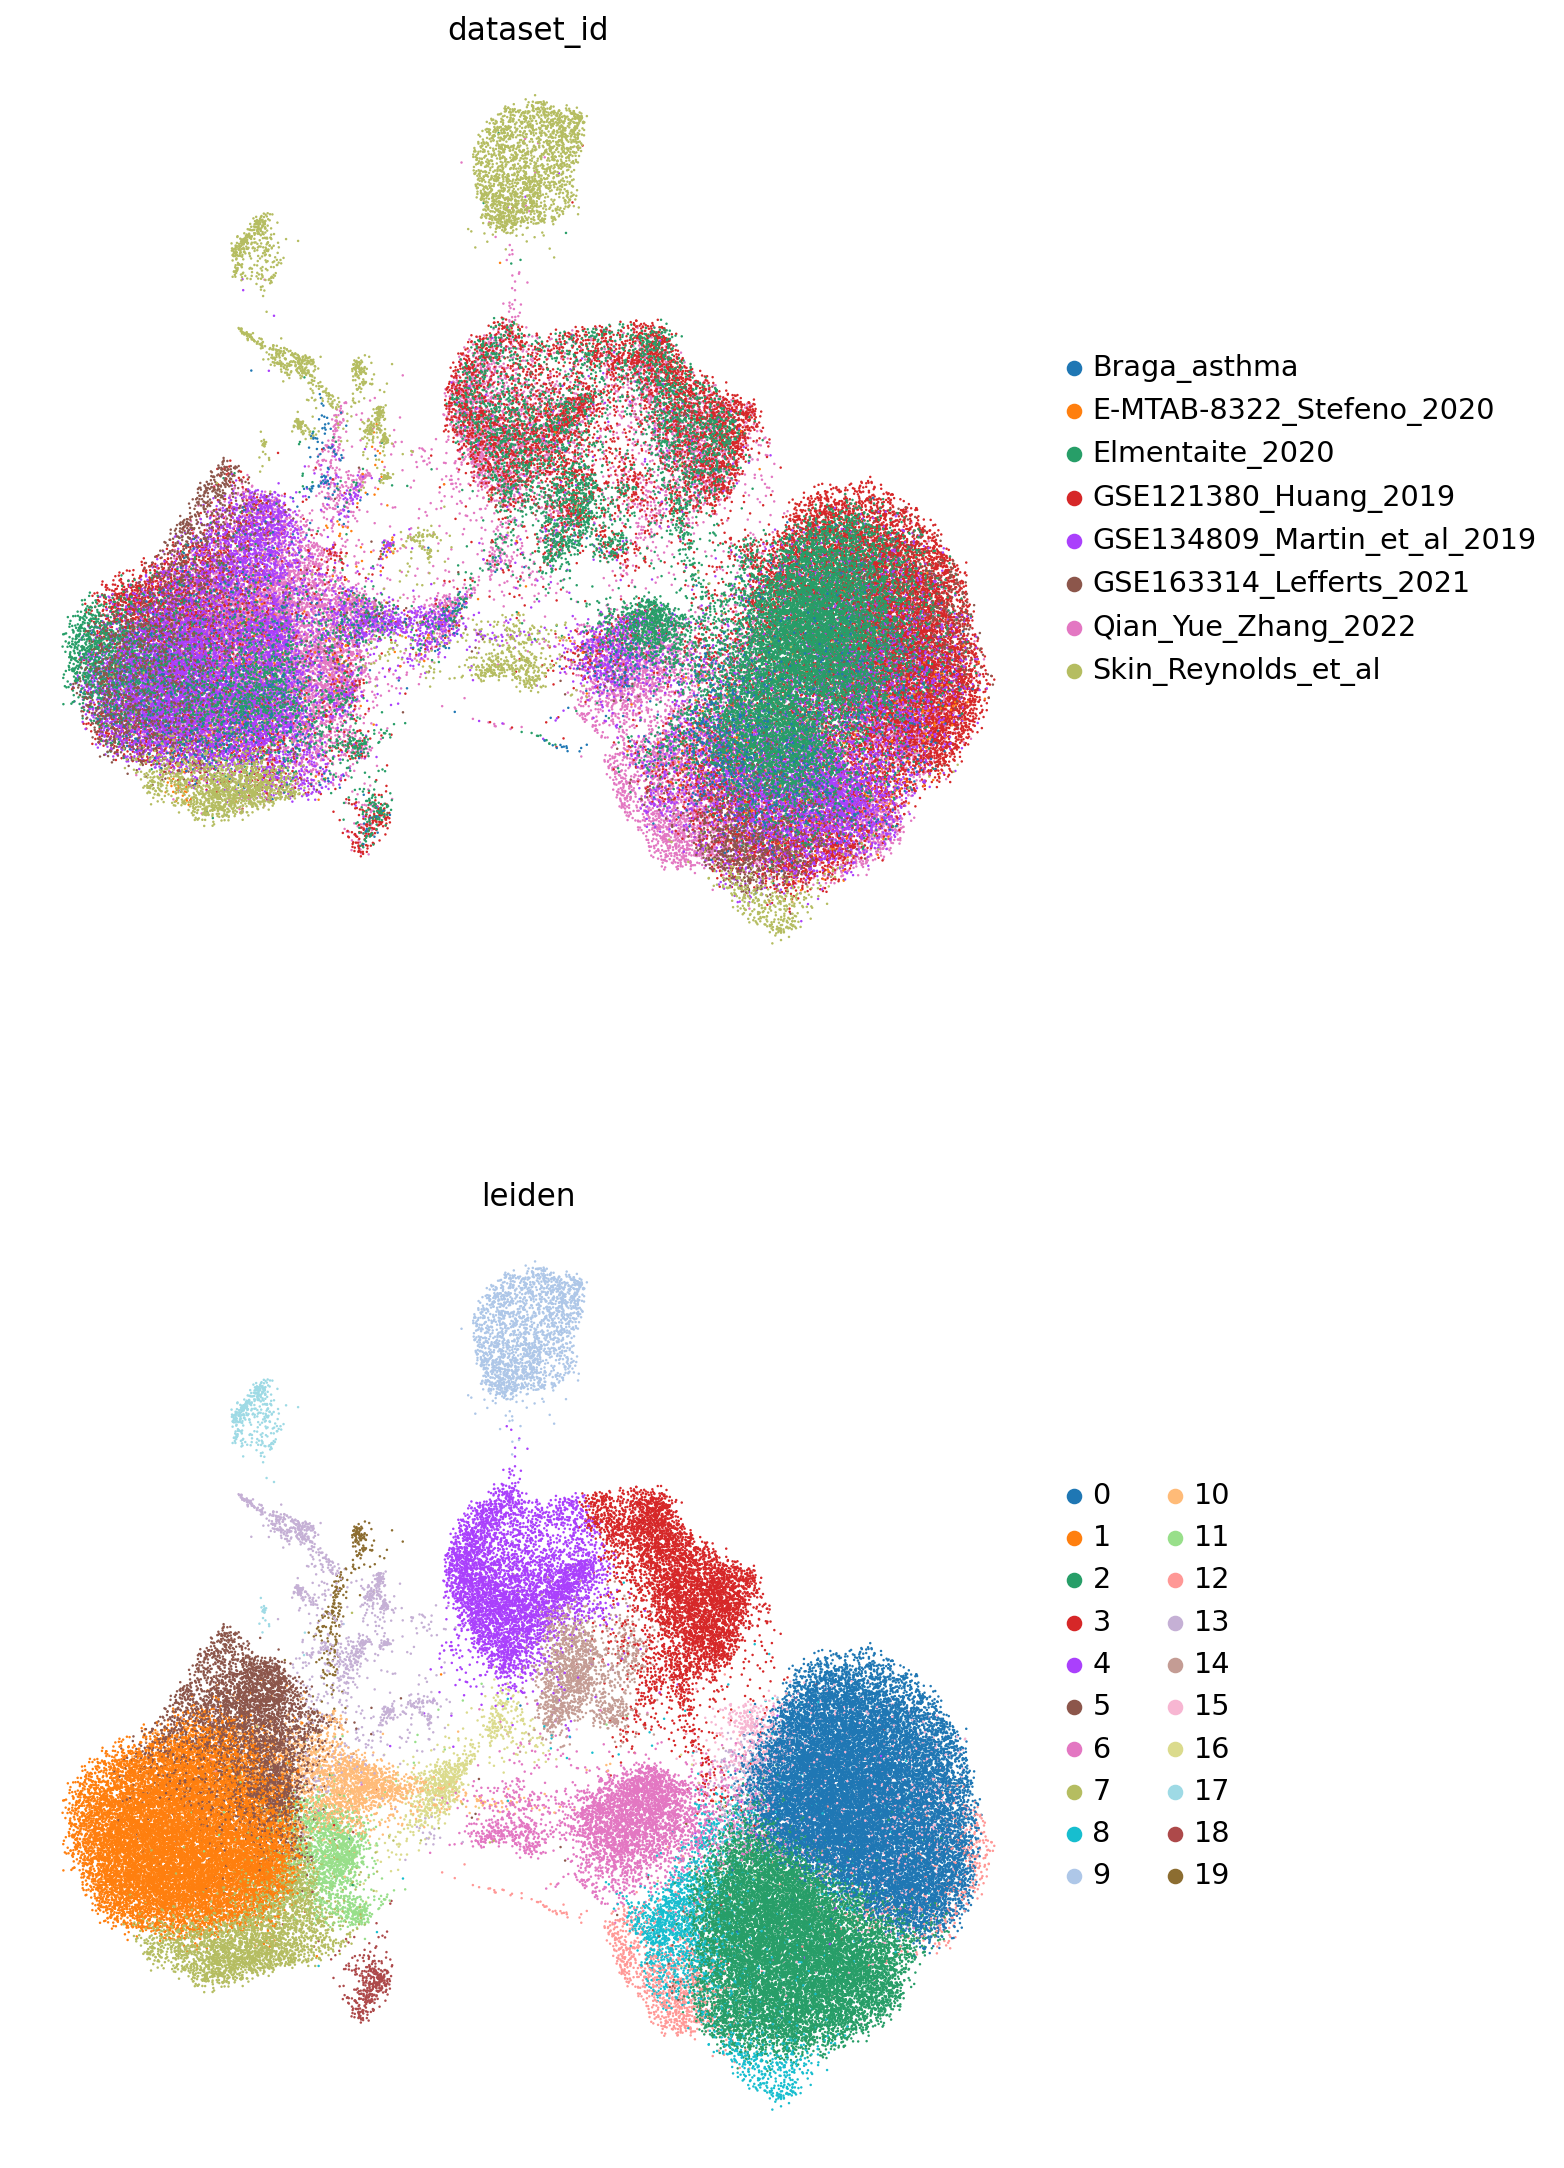

/var/tmp/ipykernel_137848/4267755793.py:44: ImplicitModificationWarning: Setting element `.obsm['X_umap']` of view, initializing view as actual.
  adata.obsm["X_umap"] = adata_hvg.obsm["X_umap"]


Plot UMAP of the full adata...


/opt/conda/envs/autoimmune/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/opt/conda/envs/autoimmune/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/opt/conda/envs/autoimmune/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/opt/conda

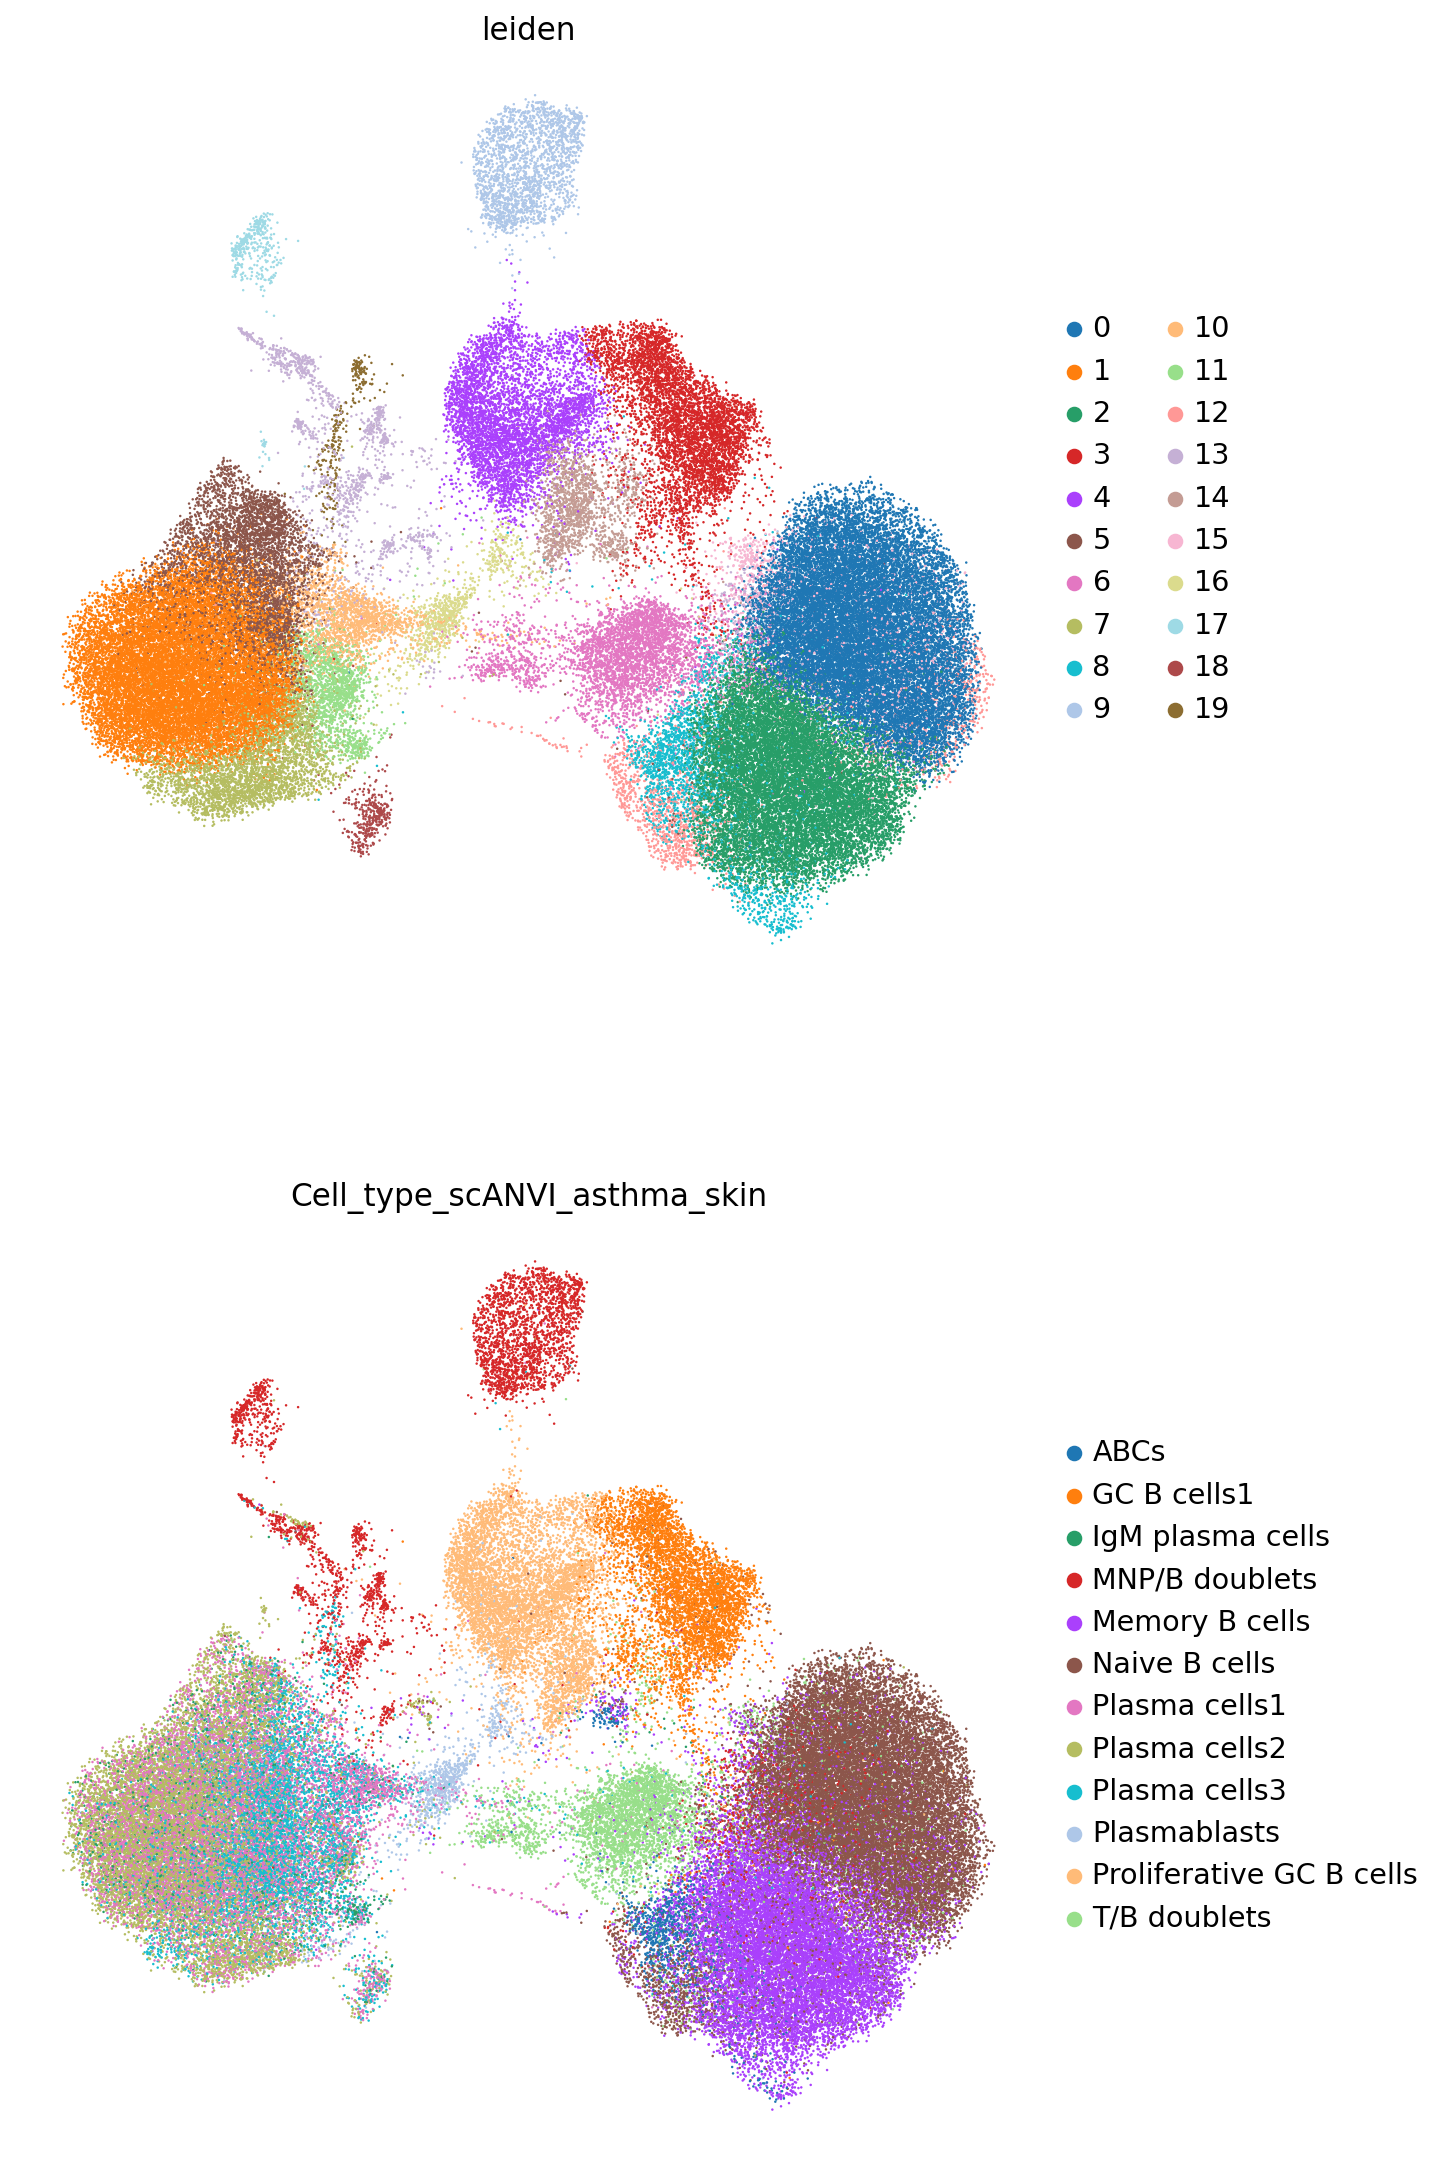

In [47]:
adata_b_cell = reintegrate_subset(adata=adata_b_cell, n_hgv=3000, n_layers=3)

In [48]:
adata_b_cell.obs['Cell_type_scANVI2'] = adata_b_cell.obs.Cell_type_scANVI_asthma_skin

In [49]:
#cmtx = sc.metrics.confusion_matrix("Cell_type_scANVI2", "Cell_type_scANVI", adata_b_cell.obs)
#sns.heatmap(cmtx)

/opt/conda/envs/autoimmune/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/opt/conda/envs/autoimmune/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/opt/conda/envs/autoimmune/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/opt/conda

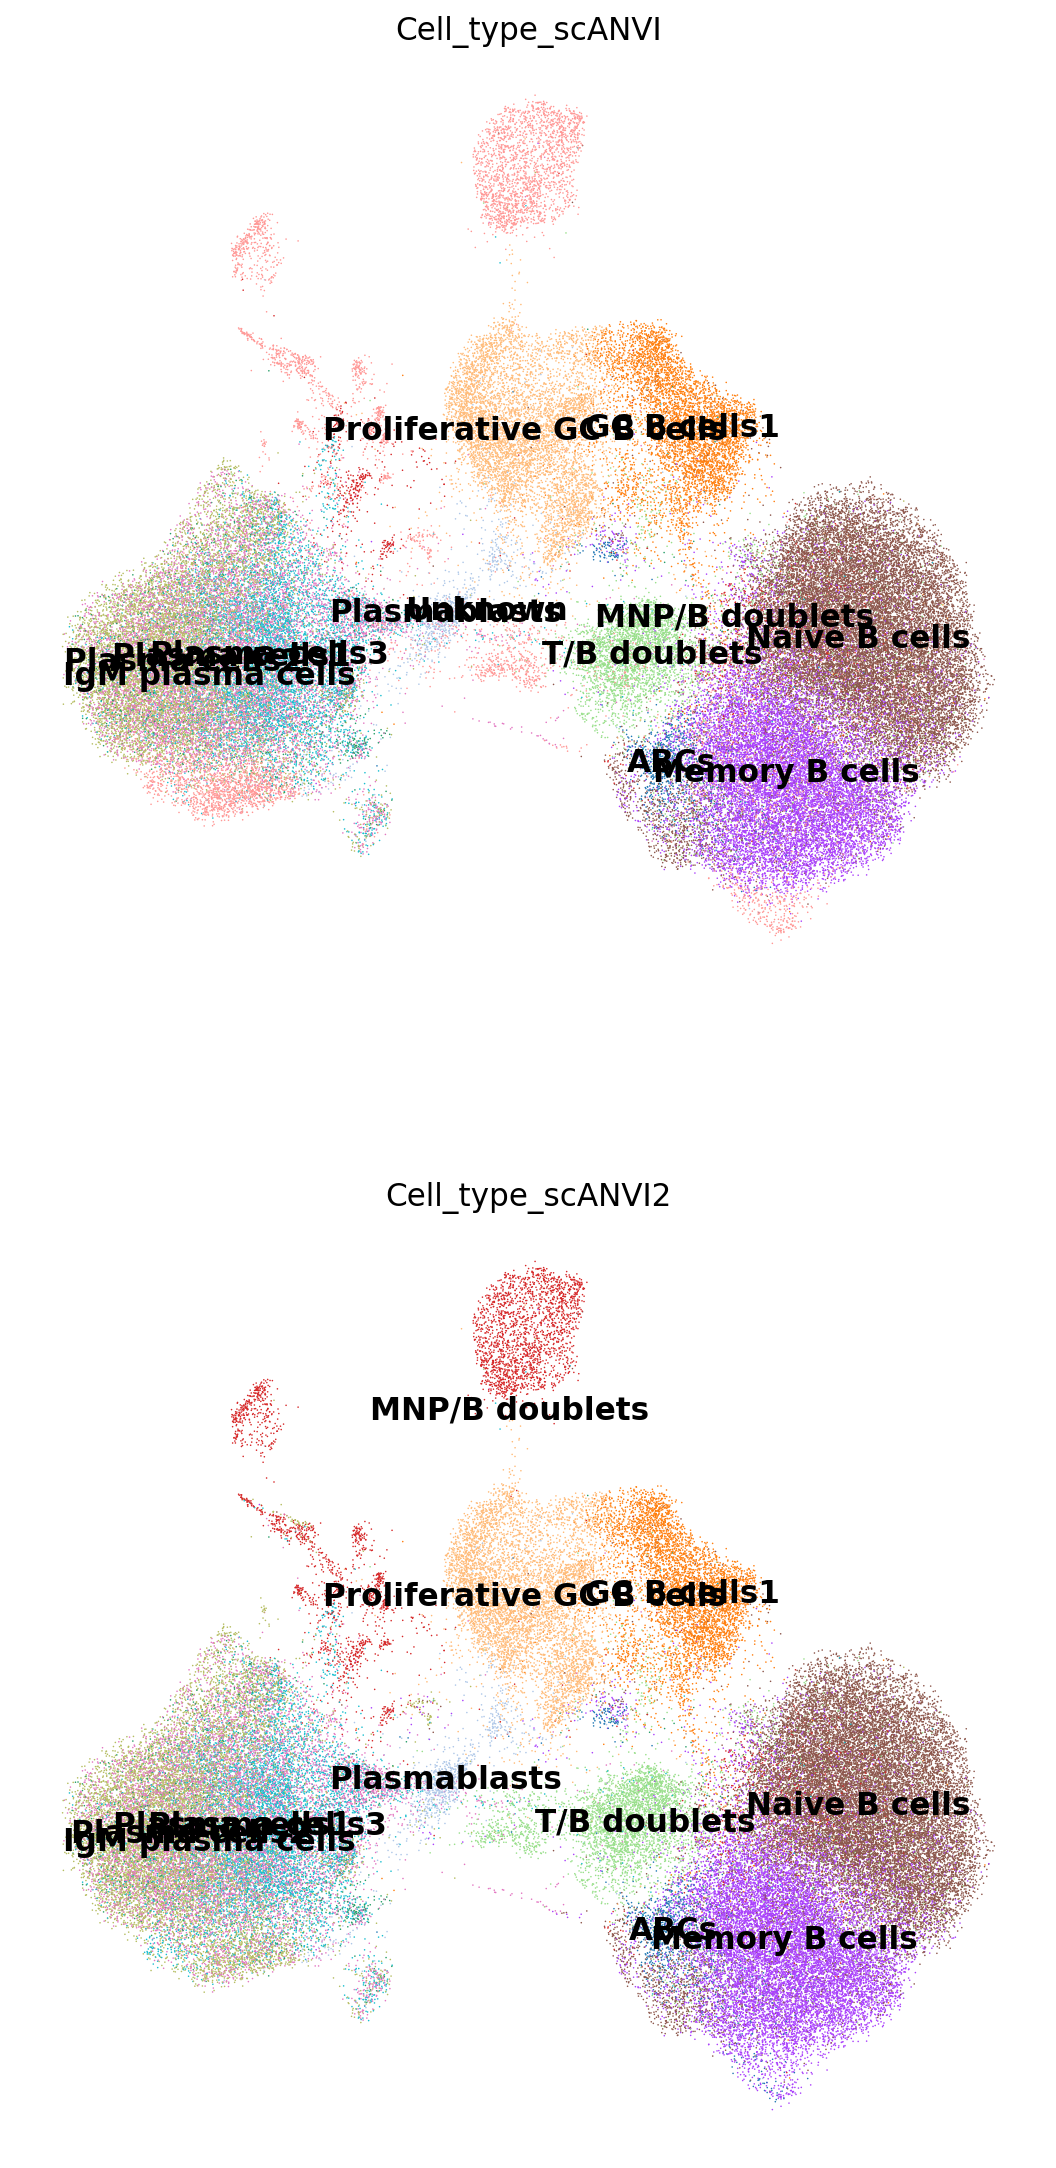

In [50]:
sc.pl.umap(
    adata_b_cell,
    color=['Cell_type_scANVI', 'Cell_type_scANVI2'],
    frameon=False,
    size=2,
    ncols=1,
    use_raw=True,
    legend_loc="on data"
)

In [51]:
adata_b_cell.obs = adata_b_cell.obs[['tissue', 'disease', 'donor_id', 'dataset_id', 'sex',
       'development_stage', 'batch', 'majority_voting', 'conf_score',
       '_scvi_batch', 'cell_type', '_scvi_labels', 'barcodes',
       'disease_status', 'age', 'developmental_stage', 'barcode', 'sample_id',
       'Site', 'Enrichment', 'Location', 'full_clustering',
       'log1p_total_counts', 'Cell_type_scANVI', 'disease_short',
       'nhood_kth_distance', 'tissue_harmo', 'disease_short_2', 'tissue_short',
       'disease_tissue', 'cell_source',
       'n_counts', 'doublet_scores', 'predicted_labels', 'over_clustering',
       'main_predicted_cell_groups', 'leiden', 'ref_query',
       'disease_label_trans', 'Cell_type_scANVI2']]

In [52]:
adata_b_cell.obs.tissue_short = adata_b_cell.obs.tissue_short.astype("category")

In [54]:
adata_b_cell.write_h5ad("result_scvi/Myeloid_B_T_From_Tissue/scVI_after_label_trans/B_cells_From_Tissue_Subset_with_asthma_skin.h5ad")

### Save 

In [ ]:
def save_x_scvi(adata,data_dir, file_name, vae):
    """
    data_dir path to save scvi embedding
    file_name name for example Immune_compartment_PBMC
    """
   # x_scanvi = vae.get_latent_representation(adata)
    outname = "{fname}.scVI_out.npy".format(fname=file_name)
    #modelname = "{fname}_scvi_model".format(fname=file_name)
    #np.save(data_dir + outname, x_scanvi)
    #vae.save(data_dir + modelname, overwrite=True)
    #pd.DataFrame(adata.obs).to_csv(data_dir+outname+".obs.csv")
    np.save(data_dir + file_name+".UMAP.npy", adata.obsm["X_umap"])
    
    #umap and obs as df
    
    umap = adata.obsm["X_umap"]
    
    umap = pd.DataFrame(umap, columns=["umap1", "umap2"])
    obs = adata.obs
    umap.index = obs.index
    obs["umap1"] = umap.umap1
    obs["umap2"] = umap.umap2
    obs.to_csv("Obs_umap_" + file_name + "scVI_from_gpu.csv")

In [ ]:
#adata = sc.read_h5ad('Myeloid_B_T_From_Tissue_label_transfert_Subset_annotated_Milo_3K.h5ad')

In [ ]:
 #save_x_scvi(adata=adata, data_dir="result_scvi/Myeloid_B_T_From_Tissue/", file_name="scVI_Myeloid_B_T_From_Tissue_asthma_skin", vae=vae)

In [ ]:
#umap = adata.obsm["X_umap"]

In [ ]:
#umap = pd.DataFrame(umap, columns=["umap1", "umap2"])

In [ ]:
#umap

In [ ]:
#obs = adata.obs

In [ ]:
#umap.index = obs.index

In [ ]:
#obs["umap1"] = umap.umap1

#obs["umap2"] = umap.umap2

In [ ]:
#obs.umap1

In [ ]:
#obs.to_csv("Obs_Myeloid_B_T_From_PBMC_label_transfert_Subset_annotated_Milo_3K_with_UMAP_from_gpu.csv")

In [ ]:
#obs

In [55]:
!rclone copy result_scvi/ 'gdrive:gcp_gpu/data_gpu/result_scvi/'

In [ ]:
!pwd

In [ ]:
!rclone copy result_scvi/ 'gdrive:gcp_gpu/data_gpu/result_scvi/'